In [1]:
import pandas as pd
import os, sys
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import matplotlib.ticker as mtick


In [2]:
# Constants
parent_folder  = "results-test"
all_files = glob.glob(os.path.join(parent_folder, "*.csv"))
HEADERS = ["Epoch", "sources", "malign", "ban_sources", "ban_malign", "consensus", "rep_benign", "rep_malign"]
print("Found {} results".format(len(all_files)))

_DISCARD_ = True
_REPLACE_ = True

Found 15000 results


In [3]:
rc_params = {
    'font.size': 26,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'figure.figsize': (7, 5),
    'axes.facecolor': '#FFFFFF',
    'figure.dpi': 300.0,
    'xtick.labelsize': 14.0,
    'ytick.labelsize': 14.0,
    'axes.labelsize': 16.0,
    'figure.titlesize': 20
    }

sns.set_theme(style='ticks', rc=rc_params)

sns.set_palette(sns.cubehelix_palette(n_colors=3, light=0.8, start=2))
zonia_palette = sns.color_palette(["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"])

# COLORI PER I GRAFICI (e.g., barre)
# #1B2D41 #466C82 #87A0B3 #D1E1F2
# COLORE PER ACCENTO (e.g., intervallo di confidenza)
# #A8D5BA

# https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4

# plt.rcParams.keys()

In [4]:
print("Import results...")
_li = []
for filename in tqdm(all_files):
    _df = pd.read_csv(filename, index_col=None, header=None, names=HEADERS)
    _params = os.path.splitext(filename)[0].split("_")
    _df['rep_min'] = float(_params[1])
    _df['ratio_malign'] = float(_params[2])
    _df['alpha'] = float(_params[3])
    _df['tolerance'] = float(_params[4])
    _df['repetition'] = float(_params[5])
    _df['Algorithm'] = float(_params[6])
    _df['Arrival'] = _params[7]
    _df['beta'] = float(_params[8])
    # Local Processing
    
    if (float(_params[8]) == 1.0 and float(_params[3]) == 0.5):
        _li.append(_df)
df = pd.concat(_li, axis=0, ignore_index=True)
print("We ended up with {} rows".format(len(df)))

Import results...


  0%|          | 0/15000 [00:00<?, ?it/s]

100%|██████████| 15000/15000 [00:57<00:00, 259.99it/s]


We ended up with 23975 rows


In [5]:
# Calculate Precision and Recall
print("Calculate precision and recall")
df['Recall'] = df.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df['Precision'] = df.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")


Calculate precision and recall
Recall done
Precision done


In [6]:
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
df['Consensus Accuracy'] = df.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else 0), axis=1)
print("Consensus Accuracy done")

#df_good = df.drop(df[df['Consensus Accuracy'] == 0].index)


Consensus Accuracy done


In [7]:
# Reduce dataset for tests XXX
df_def = df.drop(df[(df.Algorithm != 2)].index)
df_endtime = df_def.drop(df_def[(df_def.Epoch < 39)].index)

df_endtime


,Epoch,sources,malign,ban_sources,ban_malign,consensus,rep_benign,rep_malign,rep_min,ratio_malign,alpha,tolerance,repetition,Algorithm,Arrival,beta,Recall,Precision,Consensus Accuracy
199,39,10,2,2,2,24.924586,0.580681,-0.661361,-0.6,0.4,0.5,3.0,3.0,2.0,bursty,1.0,1.0,1.00,1
359,39,10,5,5,5,25.182659,0.534618,-0.696054,-0.6,1.0,0.5,3.0,0.0,2.0,bursty,1.0,1.0,1.00,1
479,39,10,5,5,0,10.015724,-0.452994,0.653442,-0.4,1.0,0.5,3.0,4.0,2.0,bursty,1.0,0.0,0.00,0
519,39,10,3,4,3,24.608821,0.377393,-0.346489,-0.2,0.6,0.5,3.0,0.0,2.0,bursty,1.0,1.0,0.75,1
639,39,10,3,3,3,25.145968,0.561104,-0.539608,-0.4,0.6,0.5,3.0,1.0,2.0,bursty,1.0,1.0,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23294,39,10,3,0,0,24.948828,0.628252,-0.670285,-0.8,0.6,0.5,3.0,2.0,2.0,uniform,1.0,0.0,0.00,1
23374,39,10,1,0,0,25.086953,0.585167,-0.790863,-0.8,0.2,0.5,3.0,0.0,2.0,uniform,1.0,0.0,0.00,1
23574,39,10,3,3,3,25.005612,0.529565,-0.659194,-0.6,0.6,0.5,3.0,4.0,2.0,uniform,1.0,1.0,1.00,1
23734,39,10,3,3,3,25.008090,0.372593,-0.451645,-0.2,0.6,0.5,3.0,2.0,2.0,uniform,1.0,1.0,1.00,1


In [ ]:
# df_def = df_def.drop(df_def[df_def.alpha == 0.3].index)

df_def

In [74]:
# PLOT 1 [ DISCARD PLOT ] - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "ratio of malignous sources" is the discriminant here
img_name = "num_mal_over_time.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='ratio_malign')
        plt.legend(title='Ratio of Malicious Sources', loc='upper left')
        plt.savefig(img_name, dpi=300)
        print (img_name + "Done")

Doing min_rep_rec_over_time.png
min_rep_rec_over_time.pngDone


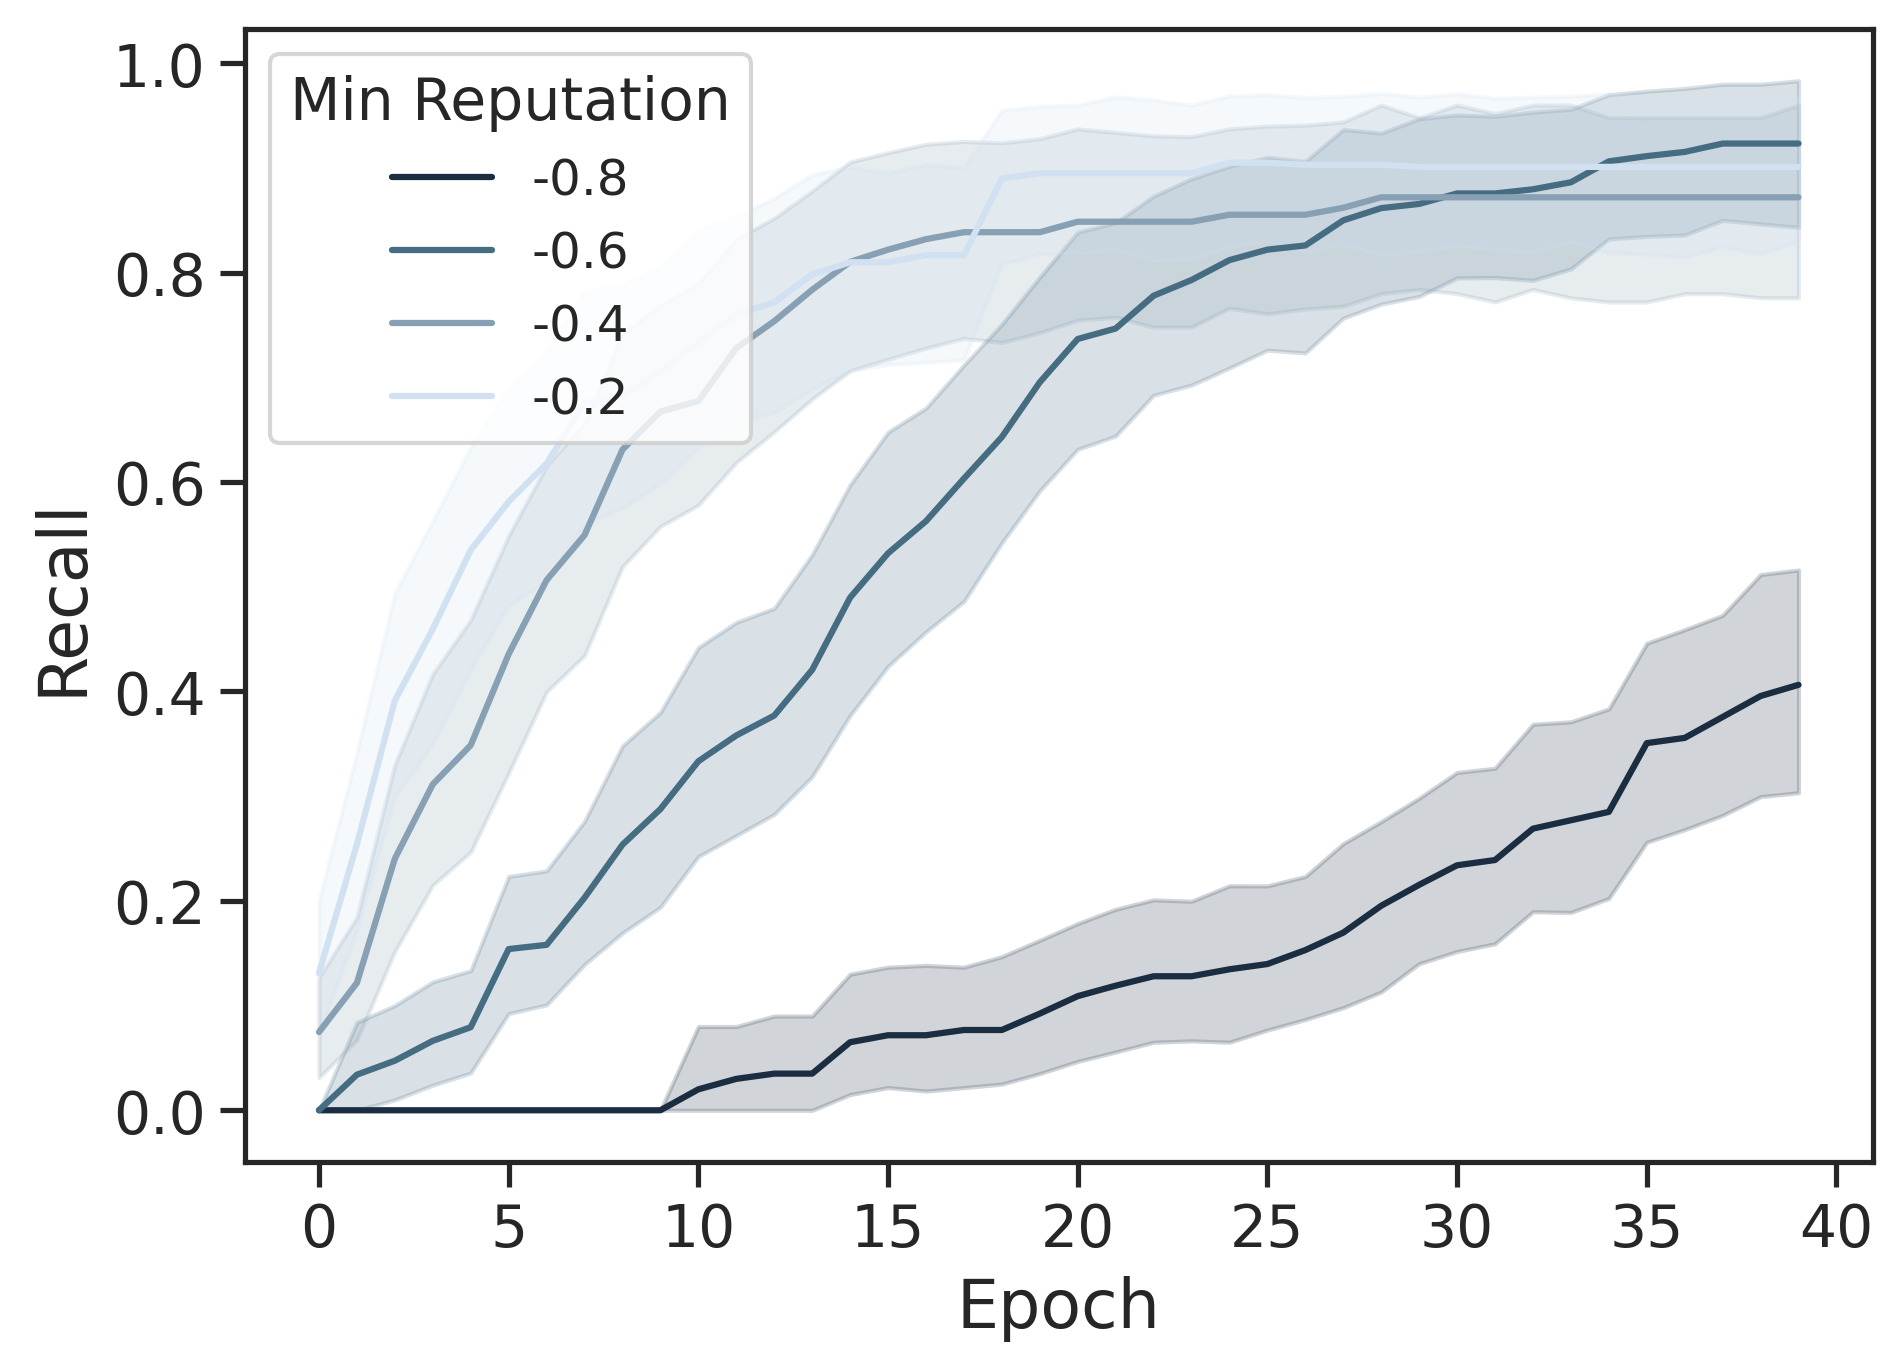

In [8]:
# PLOT 1 - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_rec_over_time.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='rep_min', palette=zonia_palette)
    plt.legend(title='Min Reputation', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

min_rep_prec_over_time.pngDone


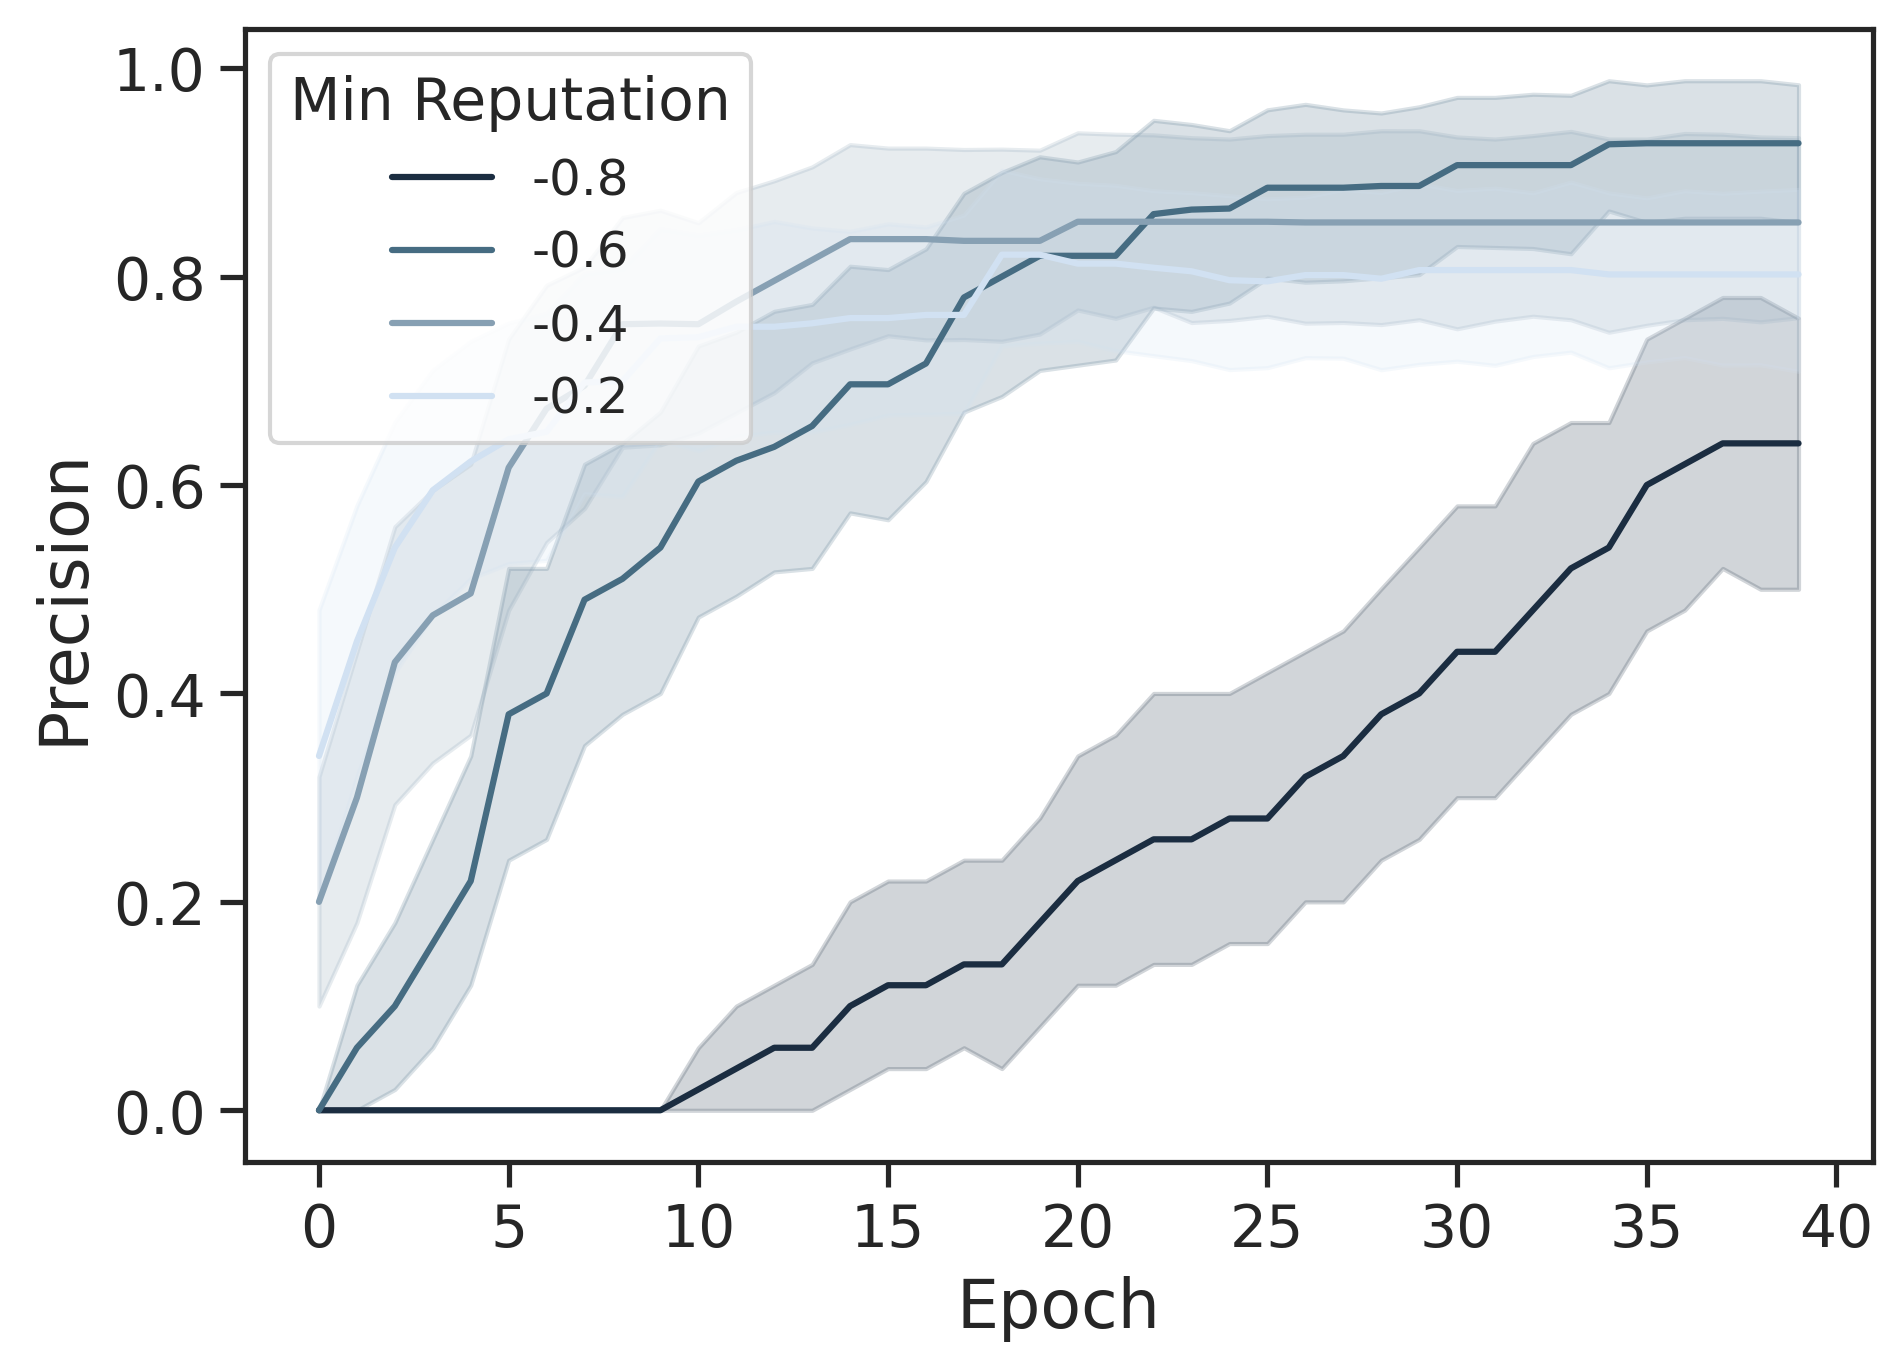

In [9]:
# PLOT 1 - PRECISION OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_prec_over_time.png"
if _REPLACE_ or not os.path.exists(img_name):
    sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min', palette=zonia_palette)
    plt.legend(title='Min Reputation', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

Doing min_rep_rec_over_alpha.png
min_rep_rec_over_alpha.pngDone


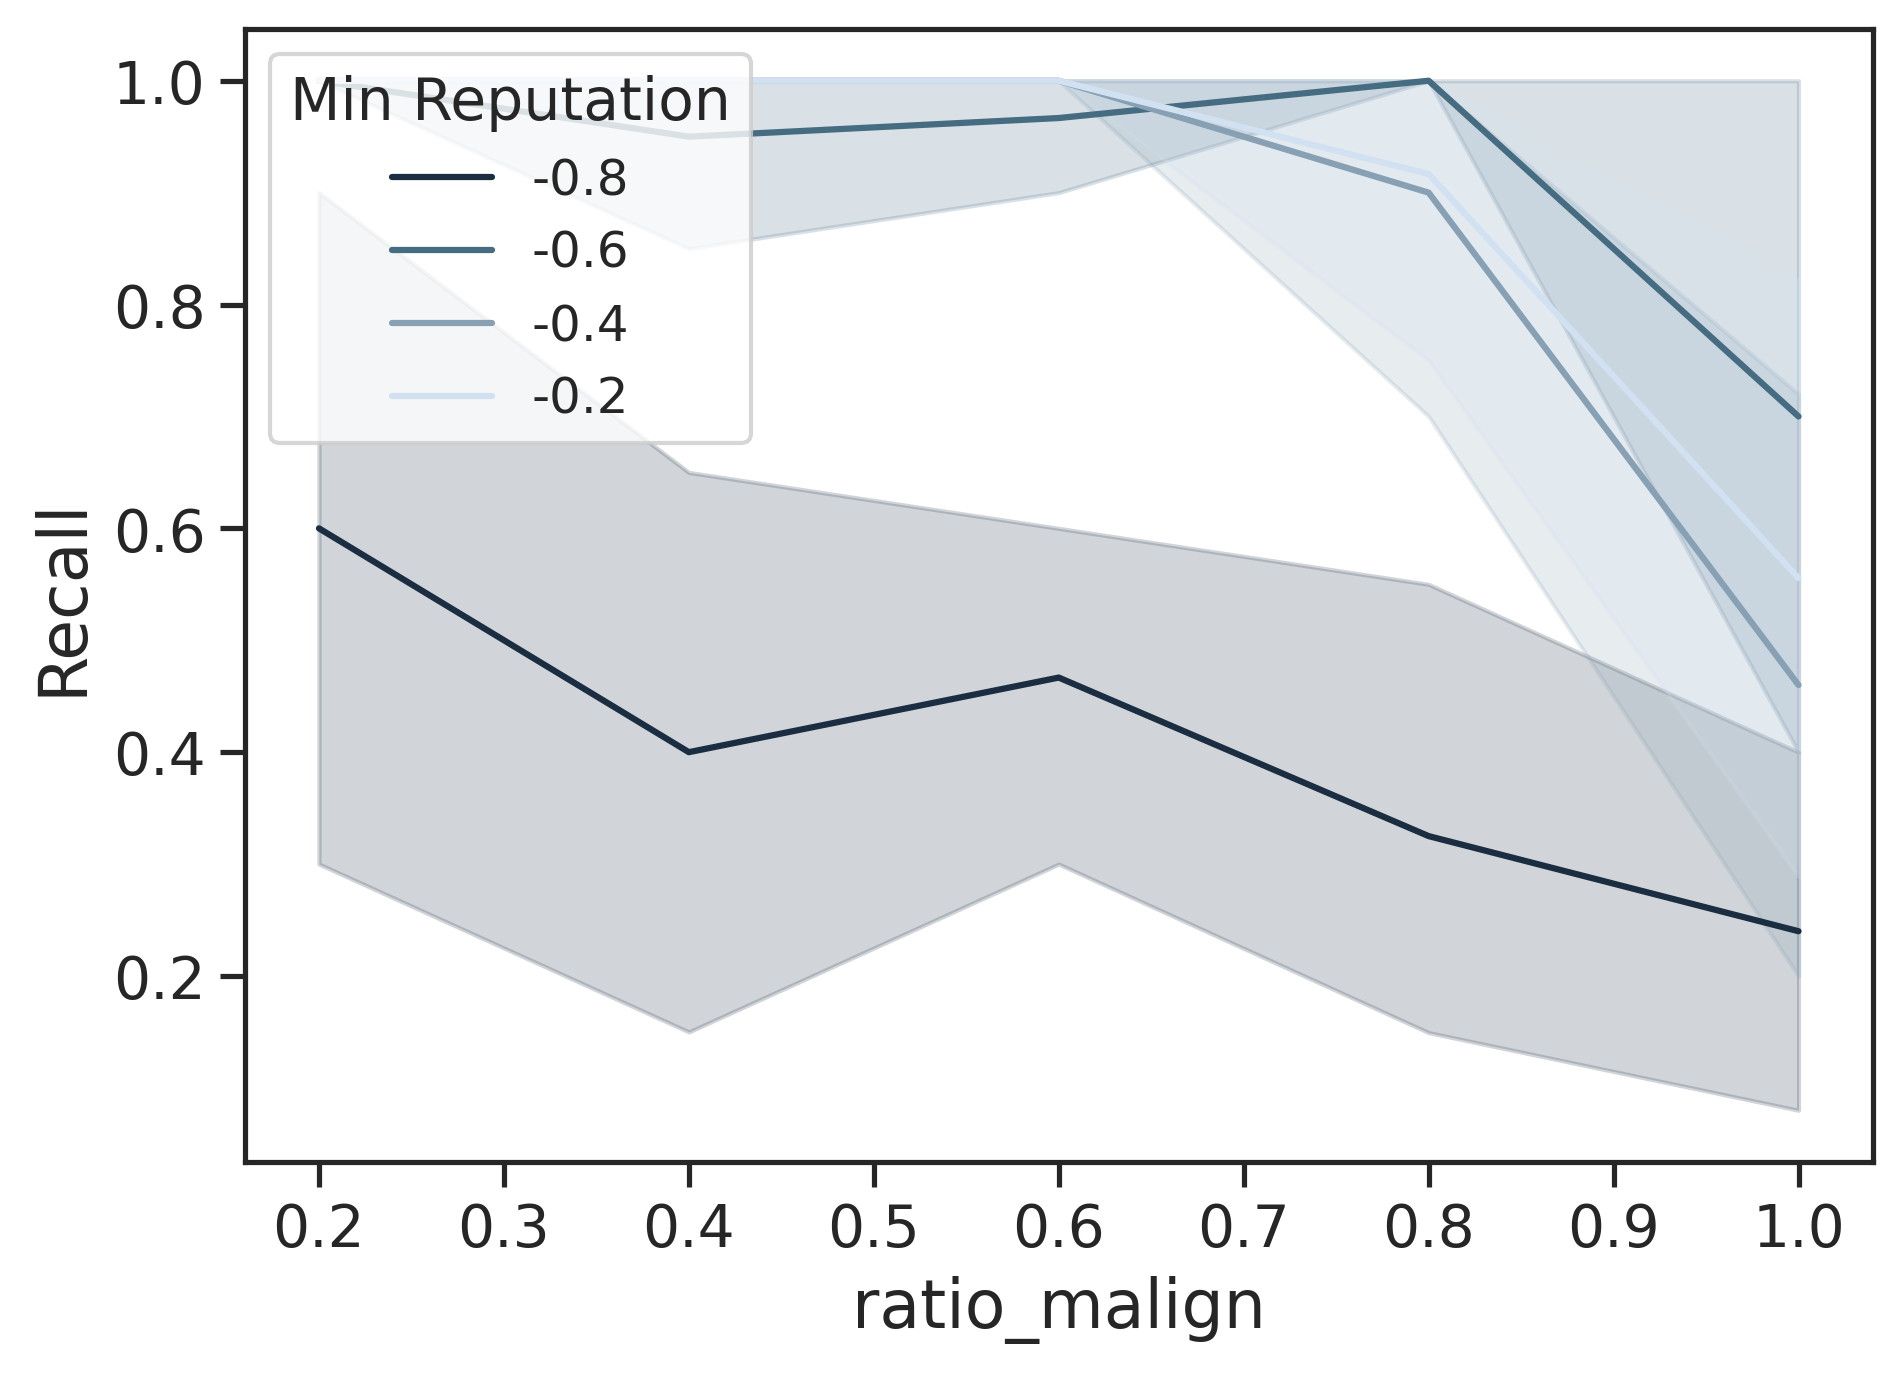

In [10]:
# PLOT 2 - RECALL OVER NUM MALICIOUS
# How many malicious sources I manage to kick out over time.
img_name = "min_rep_rec_over_alpha.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    sns.lineplot(data=df_endtime, x='ratio_malign', y='Recall', hue='rep_min', palette=zonia_palette)
    plt.legend(title='Min Reputation', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

Doing rep_benign.png


/tmp/ipykernel_325634/693203836.py:7: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=df_def, x='Epoch', y='rep_benign', hue='ratio_malign', palette=zonia_palette)


rep_benign.pngDone


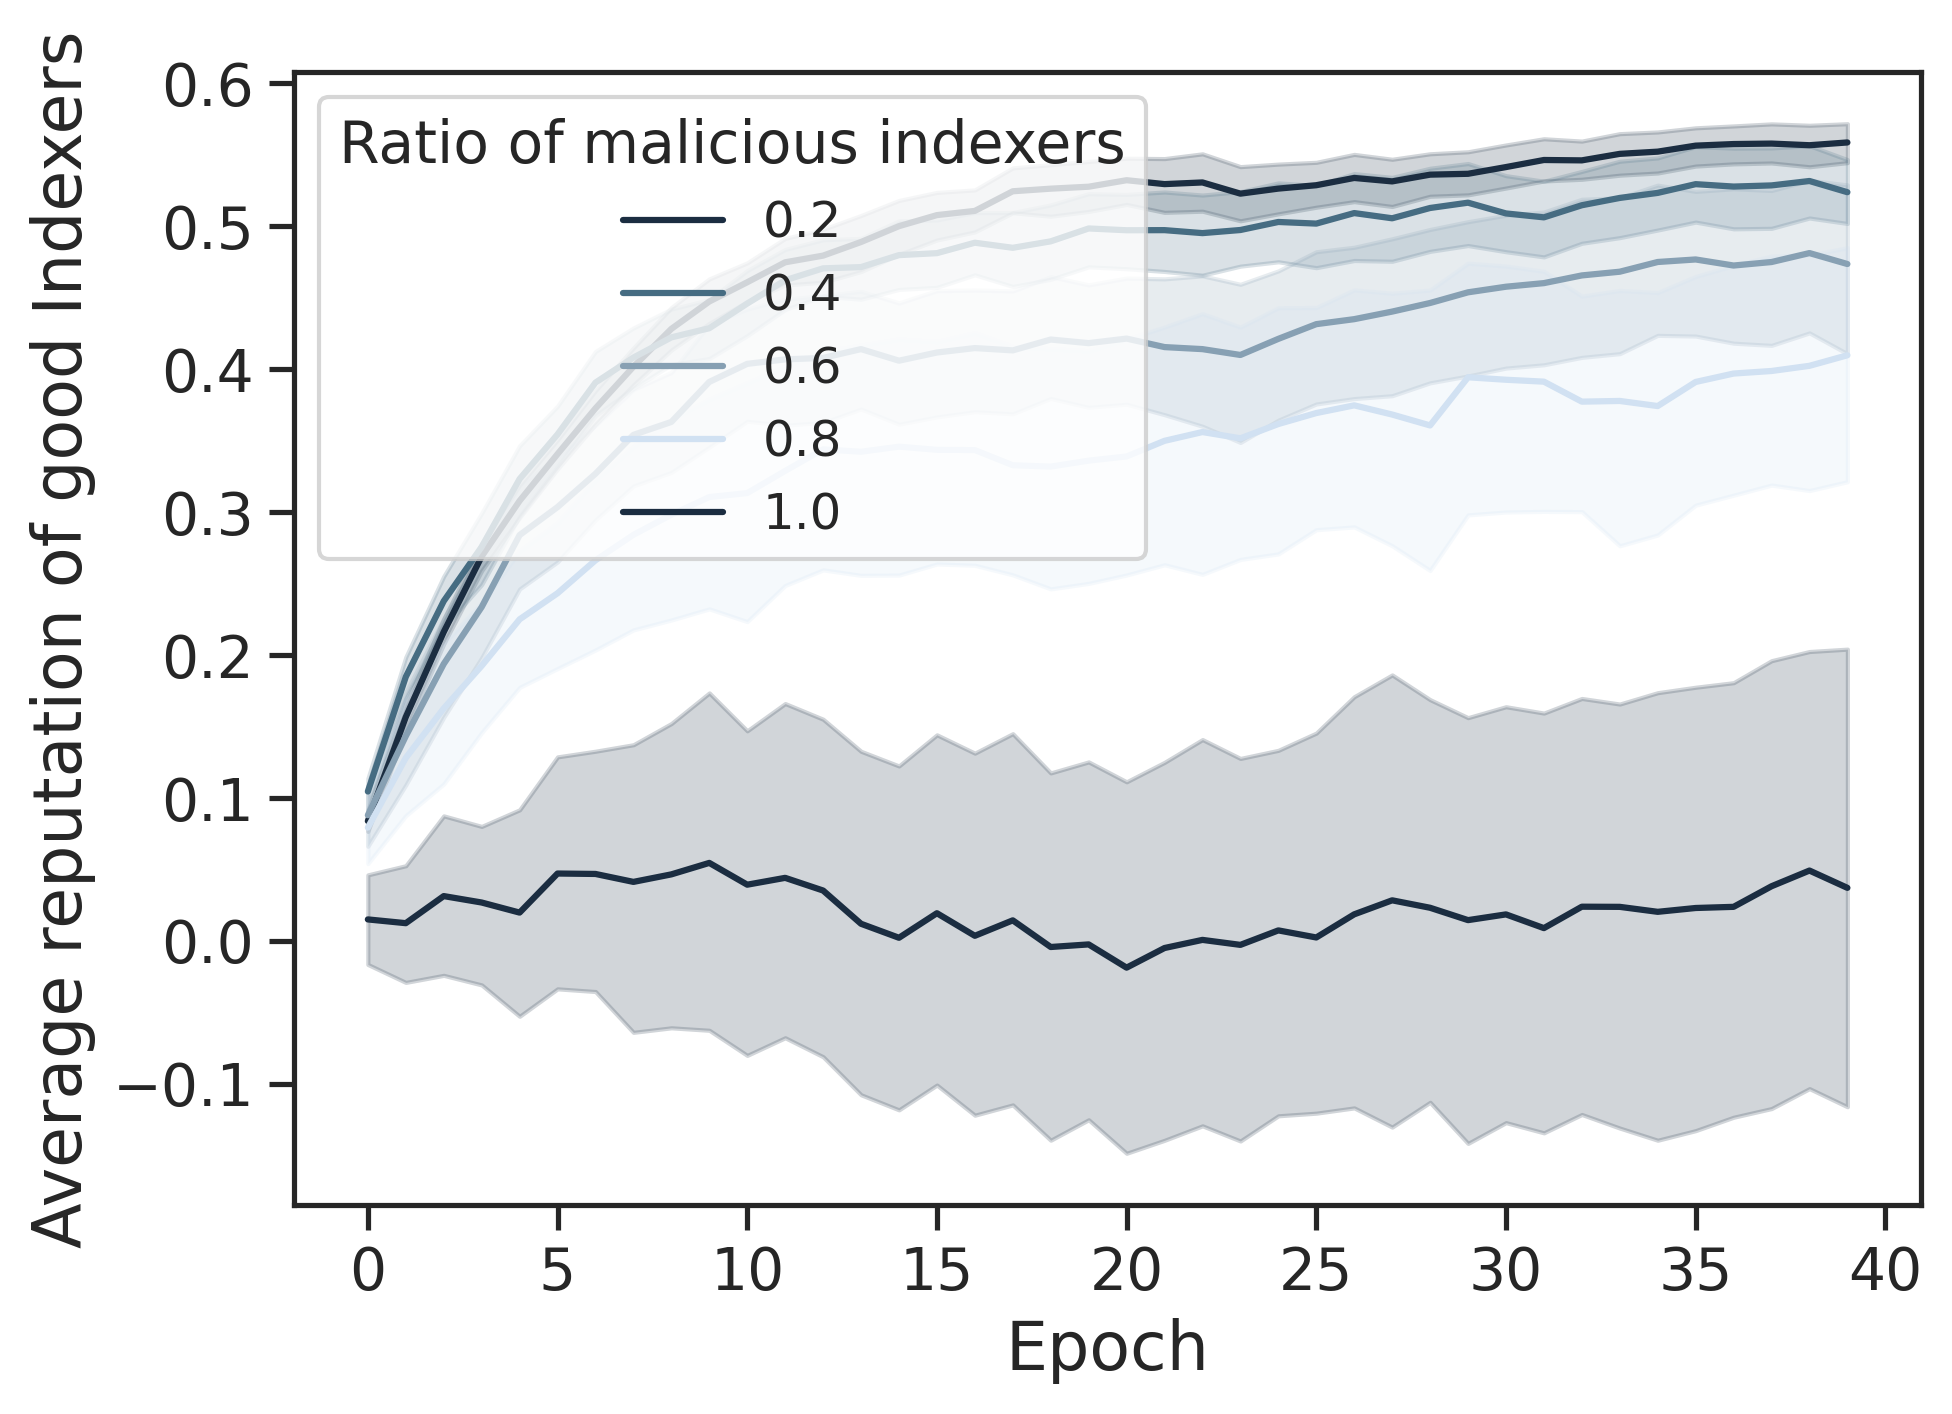

In [11]:
# PLOT 1 - Average Reputation Benign
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "rep_benign.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    sns.lineplot(data=df_def, x='Epoch', y='rep_benign', hue='ratio_malign', palette=zonia_palette)
    plt.legend(title='Ratio of malicious indexers', loc='upper left')
    plt.ylabel("Average reputation of good Indexers", fontsize=16)
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

Doing rep_malign.png


/tmp/ipykernel_325634/3470066047.py:7: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=df_def, x='Epoch', y='rep_malign', hue='ratio_malign', palette=zonia_palette)


rep_malign.pngDone


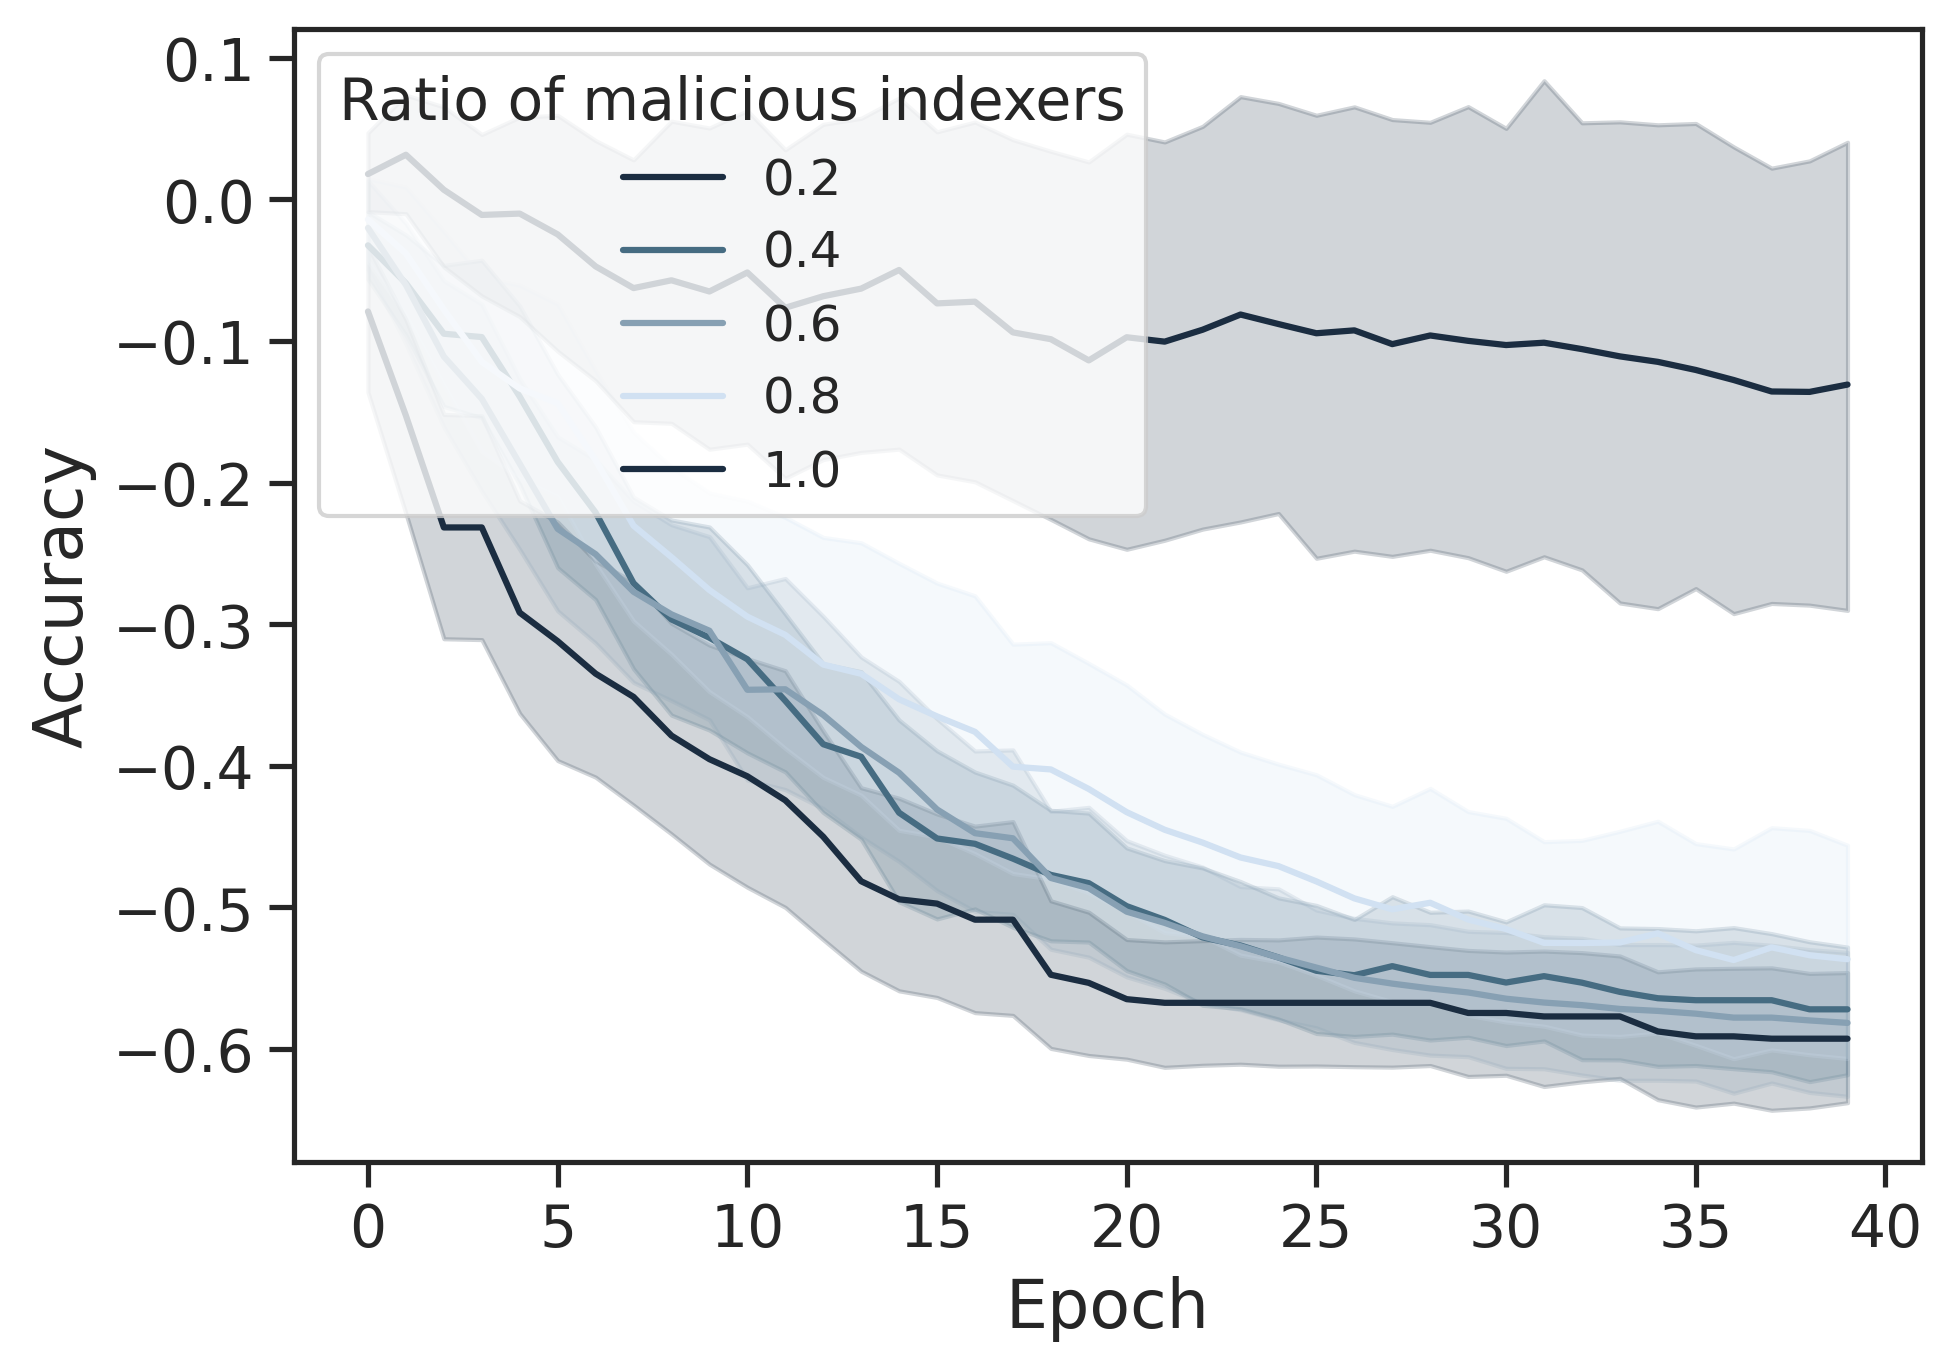

In [12]:
# PLOT 1 - Average Reputation Benign
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "rep_malign.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    sns.lineplot(data=df_def, x='Epoch', y='rep_malign', hue='ratio_malign', palette=zonia_palette)
    plt.ylabel('Accuracy', fontsize=16)
    plt.legend(title='Ratio of malicious indexers', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

impact_alpha.pngDone


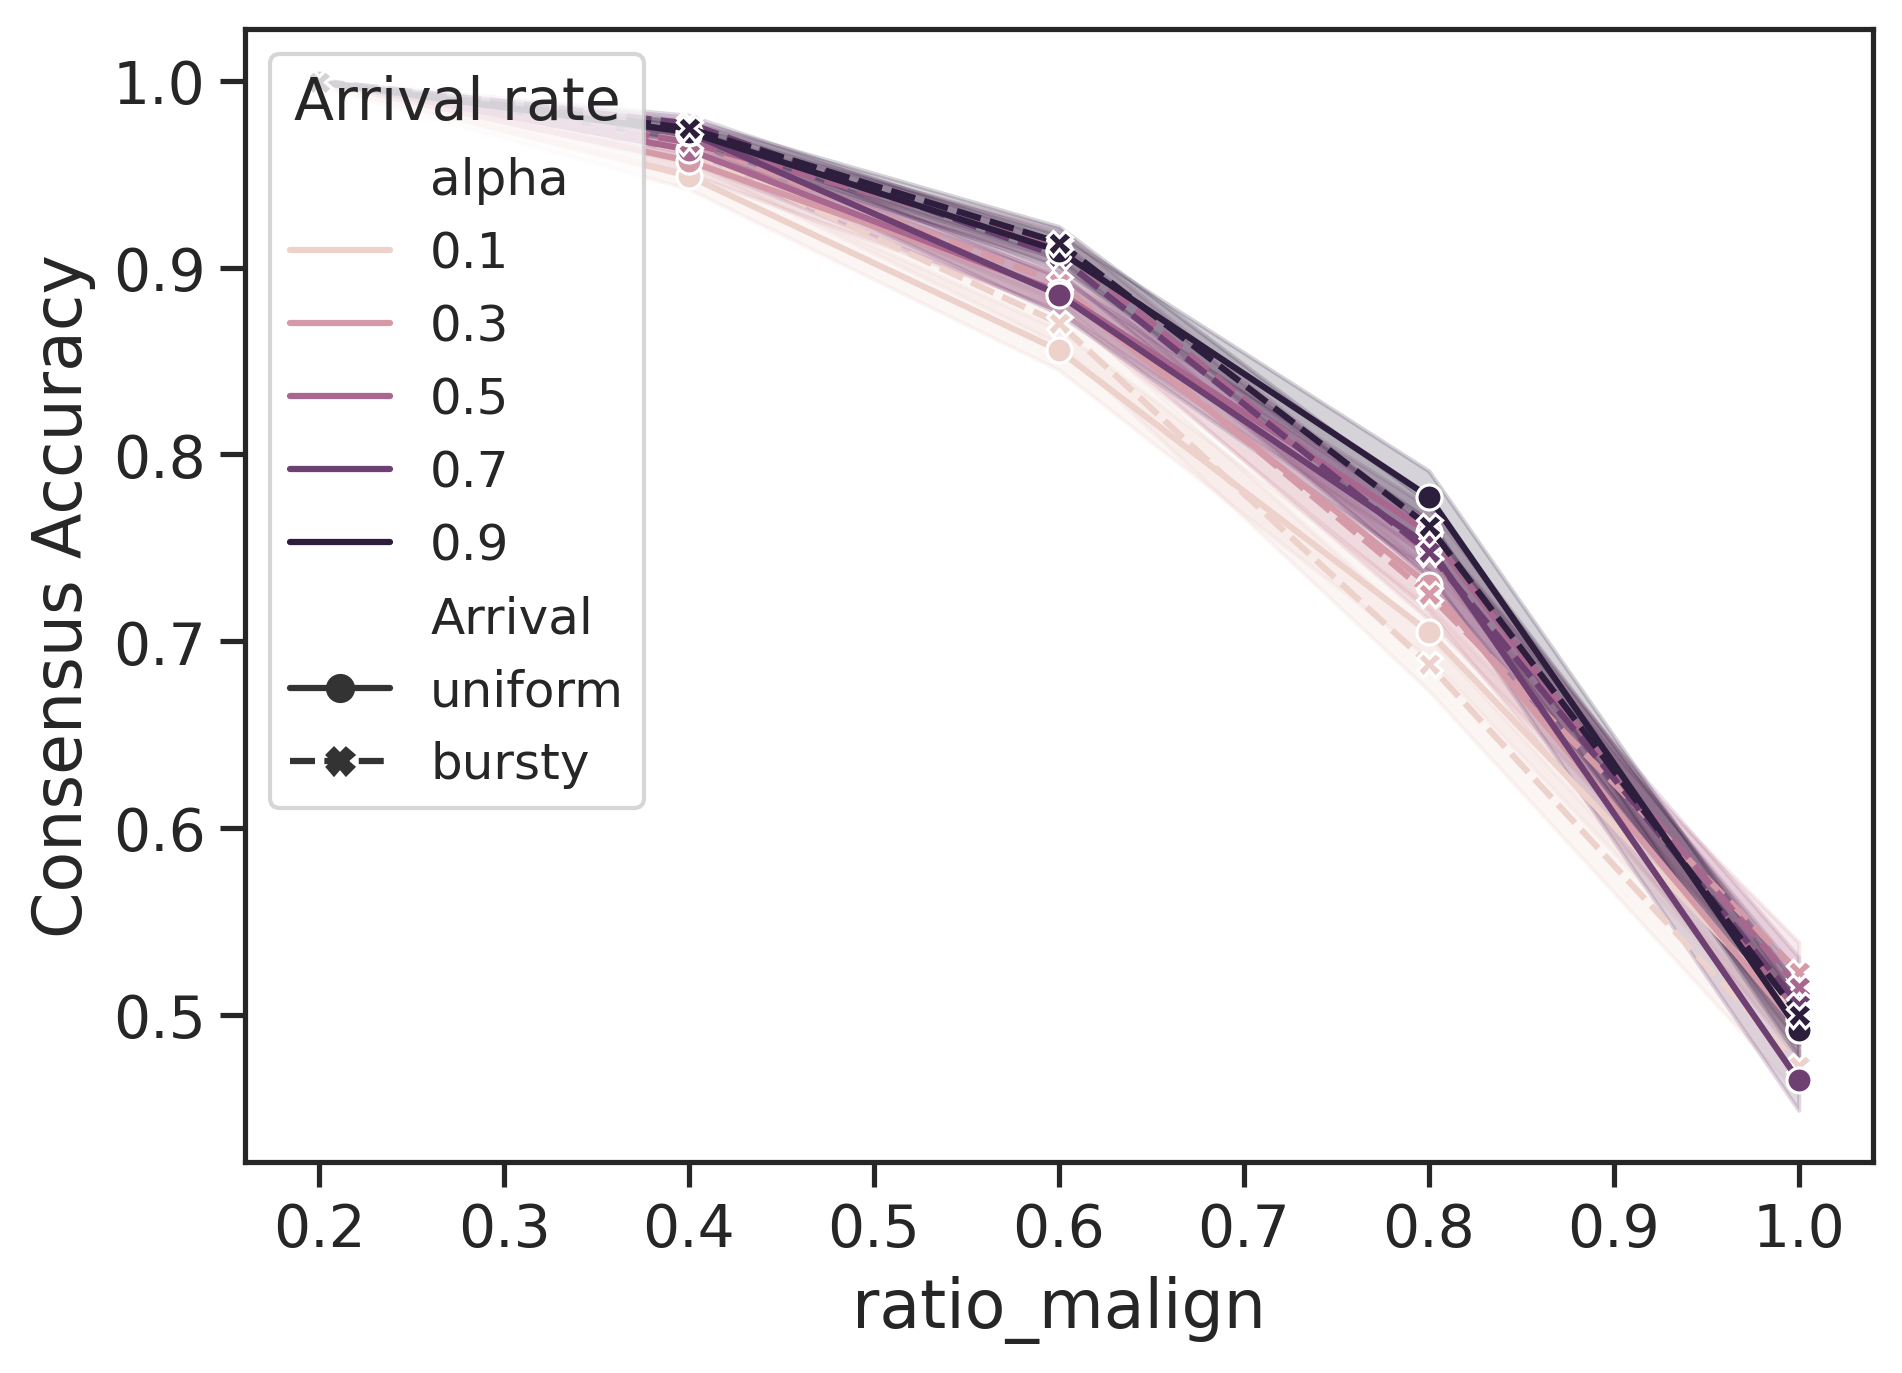

In [71]:
# PLOT 3 - IMPACT OF ALPHA
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "impact_alpha.png"
if _REPLACE_ or not os.path.exists(img_name):
    sns.lineplot(data=df_def, x='ratio_malign', y='Consensus Accuracy',hue='alpha', style='Arrival', markers=True)
    plt.legend(title='Arrival rate', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

impact_beta.pngDone


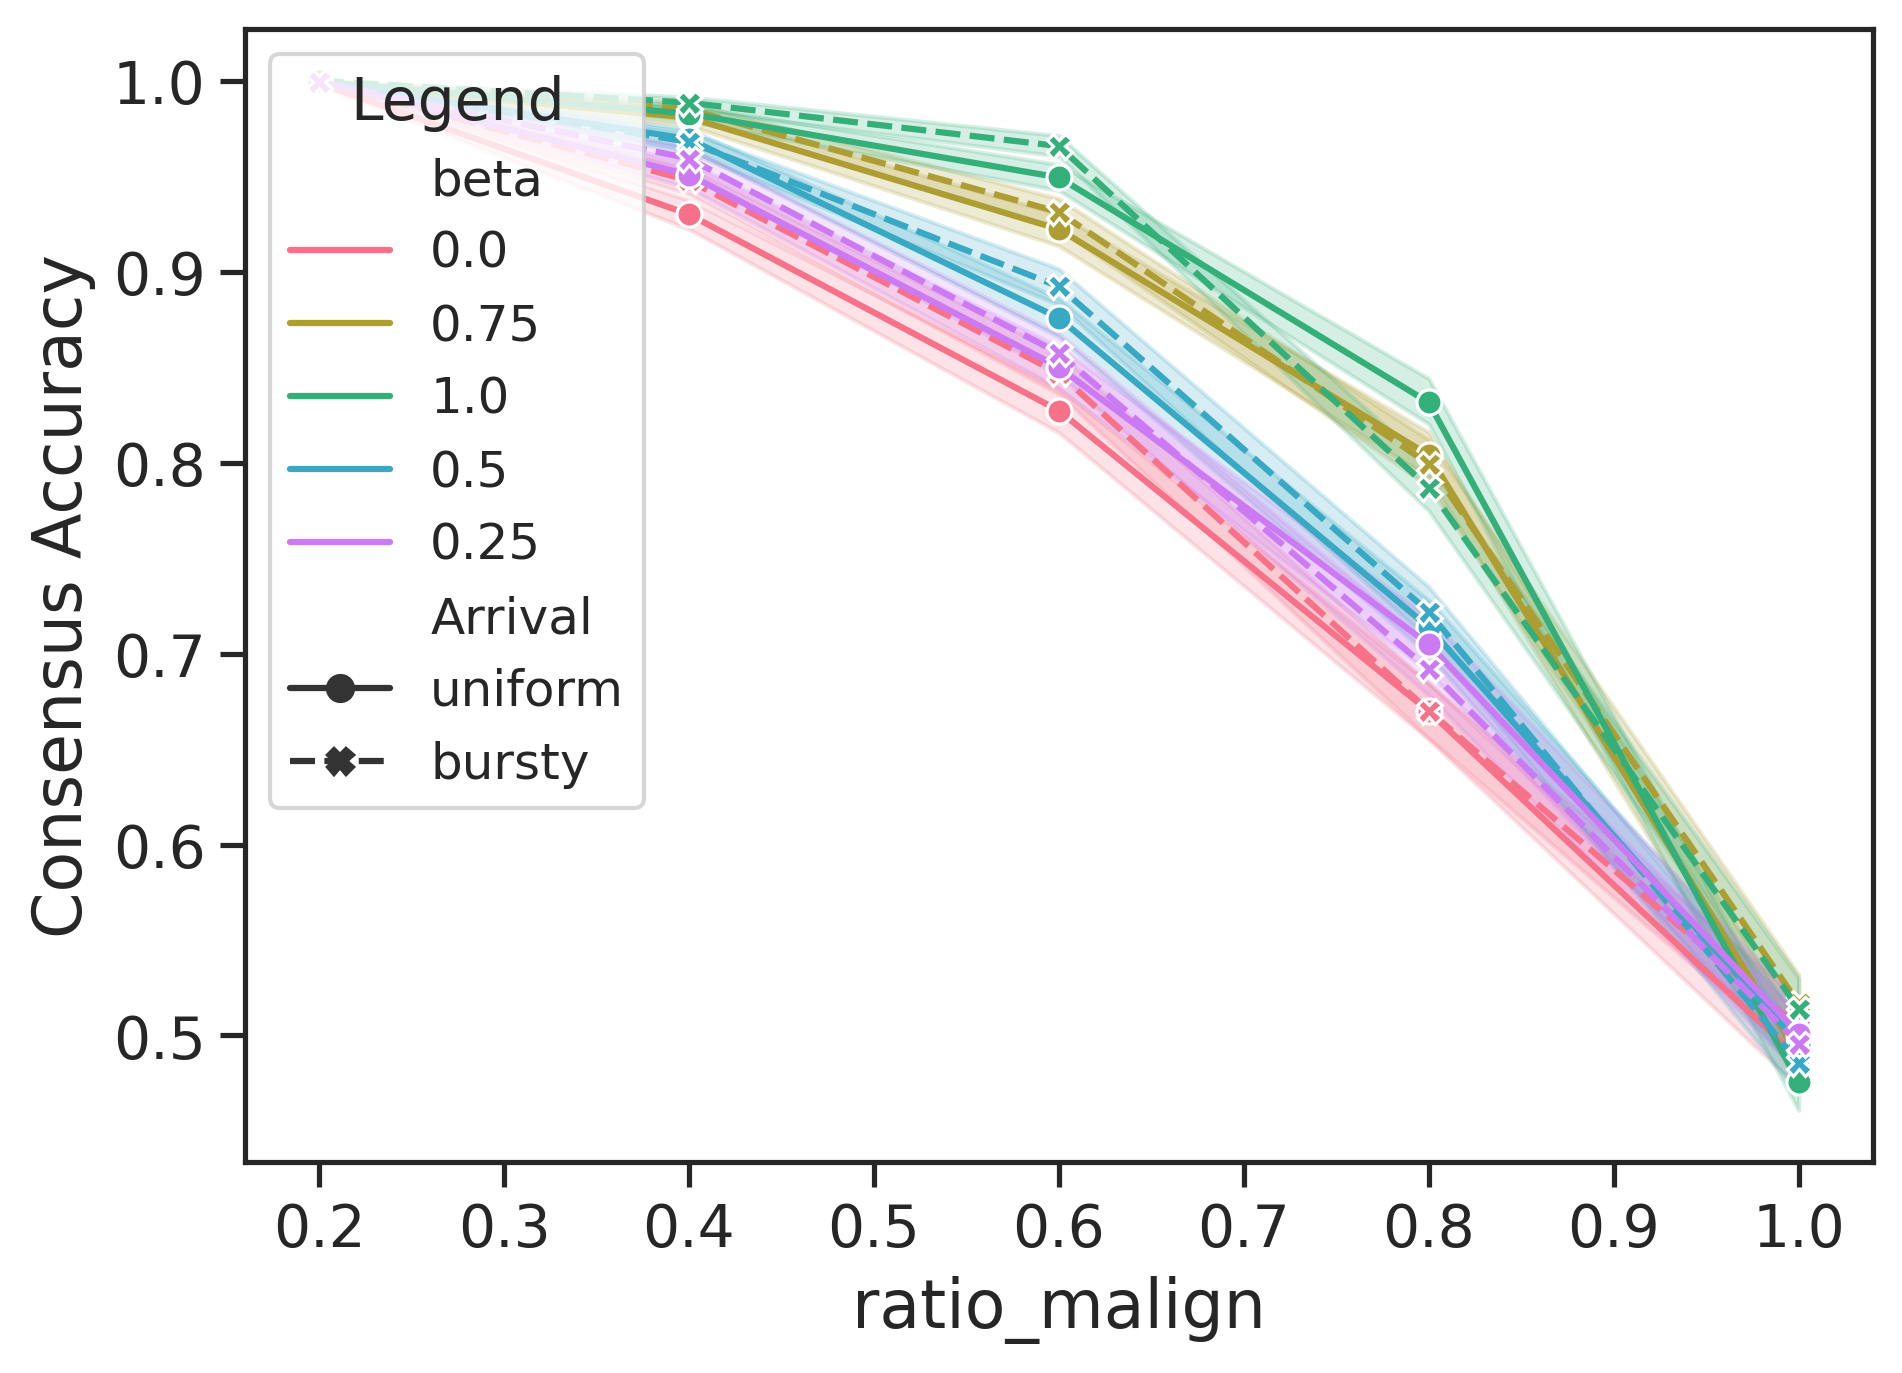

In [72]:
# PLOT 3 - IMPACT OF BETA
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "impact_beta.png"
if _REPLACE_ or not os.path.exists(img_name):
    sns.lineplot(data=df_def, x='ratio_malign', y='Consensus Accuracy',hue='beta', style='Arrival', markers=True)
    plt.legend(title='Legend', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [13]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_num_mal.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='ratio_malign', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

In [14]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_min_rep.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='rep_min', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

In [38]:
# PLOT 2 - IMPACT ON CONSENSUS ACCURACY

# Comparison of this algo with another dummy one ? Only one bar !
# Average - no kick out
# Median - with ranking - no kick out

img_name = "algorithm_comparison_bursty.png"
if (_REPLACE_ or not os.path.exists(img_name)) and not _DISCARD_:
    print("Doing " + img_name)
    ax = sns.countplot(data=df_good, x='ratio_malign', hue='Algorithm')
    for i in ax.containers:
        ax.bar_label(i, fontsize=5)
    plt.legend(title='Algorithm', loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3,
    labels=['Consensus', 'Ranking', 'Reputation'])
    ax.set_xlabel('Ratio of Malignous Sources', fontsize=16)
    ax.set_ylabel('Ratio of Accurate Responses', fontsize=16)

    plt.tight_layout()
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")


In [15]:
print("Doing the bars...")
df_bar = df.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] / 2 * 100.0), axis=1)


df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()


Doing the bars...


Doing desmo_accuracy.png


/tmp/ipykernel_325634/3450402740.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_325634/3450402740.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()


desmo_accuracy.png Done!


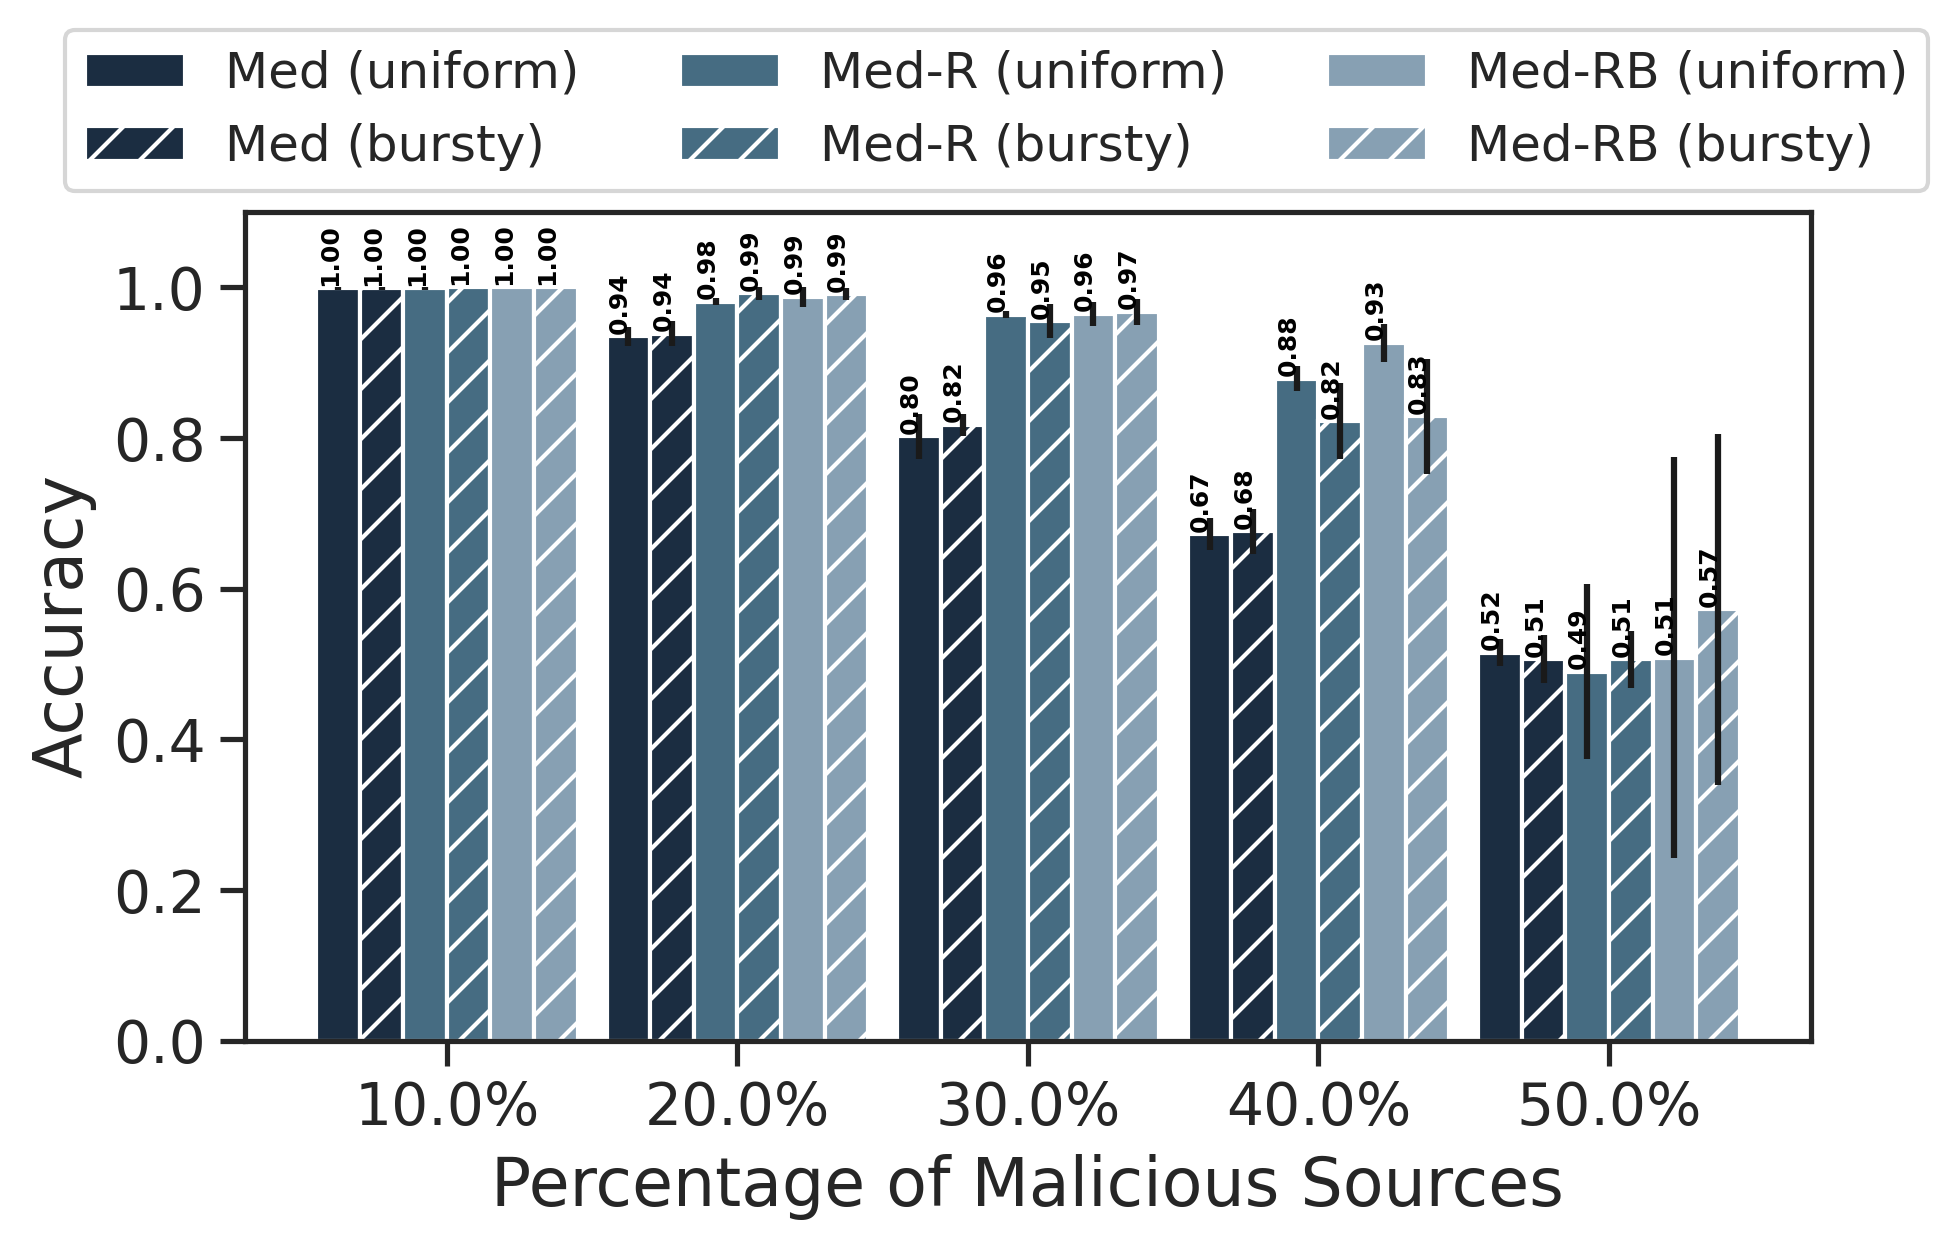

In [16]:
img_name = "desmo_accuracy.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 1.5

    colors = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('Percentage of Malicious Sources', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.25), ncol=3, labels=['Med (uniform)', 'Med (bursty)', 'Med-R (uniform)', 'Med-R (bursty)', 'Med-RB (uniform)', 'Med-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    plt.tight_layout()
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")